## Task

The following are different arrangements of data randomly generated in low-dimensional feature spaces. Use K-Means to cluster this data. Visualize the effect of different numbers of centroids on the result.

In [1]:
import numpy as np
from sklearn import datasets

In [2]:
# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=.5,
                                      noise=.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=170)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(n_samples=n_samples,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=random_state)

listofdata = [noisy_circles, noisy_moons, varied, aniso, blobs, no_structure]

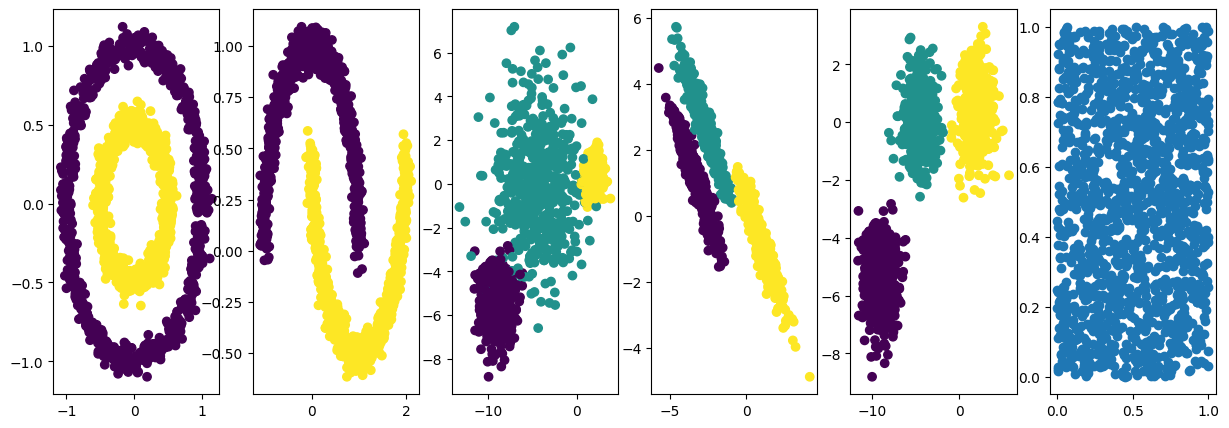

In [3]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 5)

numPlot=1
for ds in listofdata:
    plt.subplot(1,len(listofdata),numPlot)
    plt.scatter(ds[0][:,0],ds[0][:,1], c=ds[1])
    numPlot+=1

plt.show()

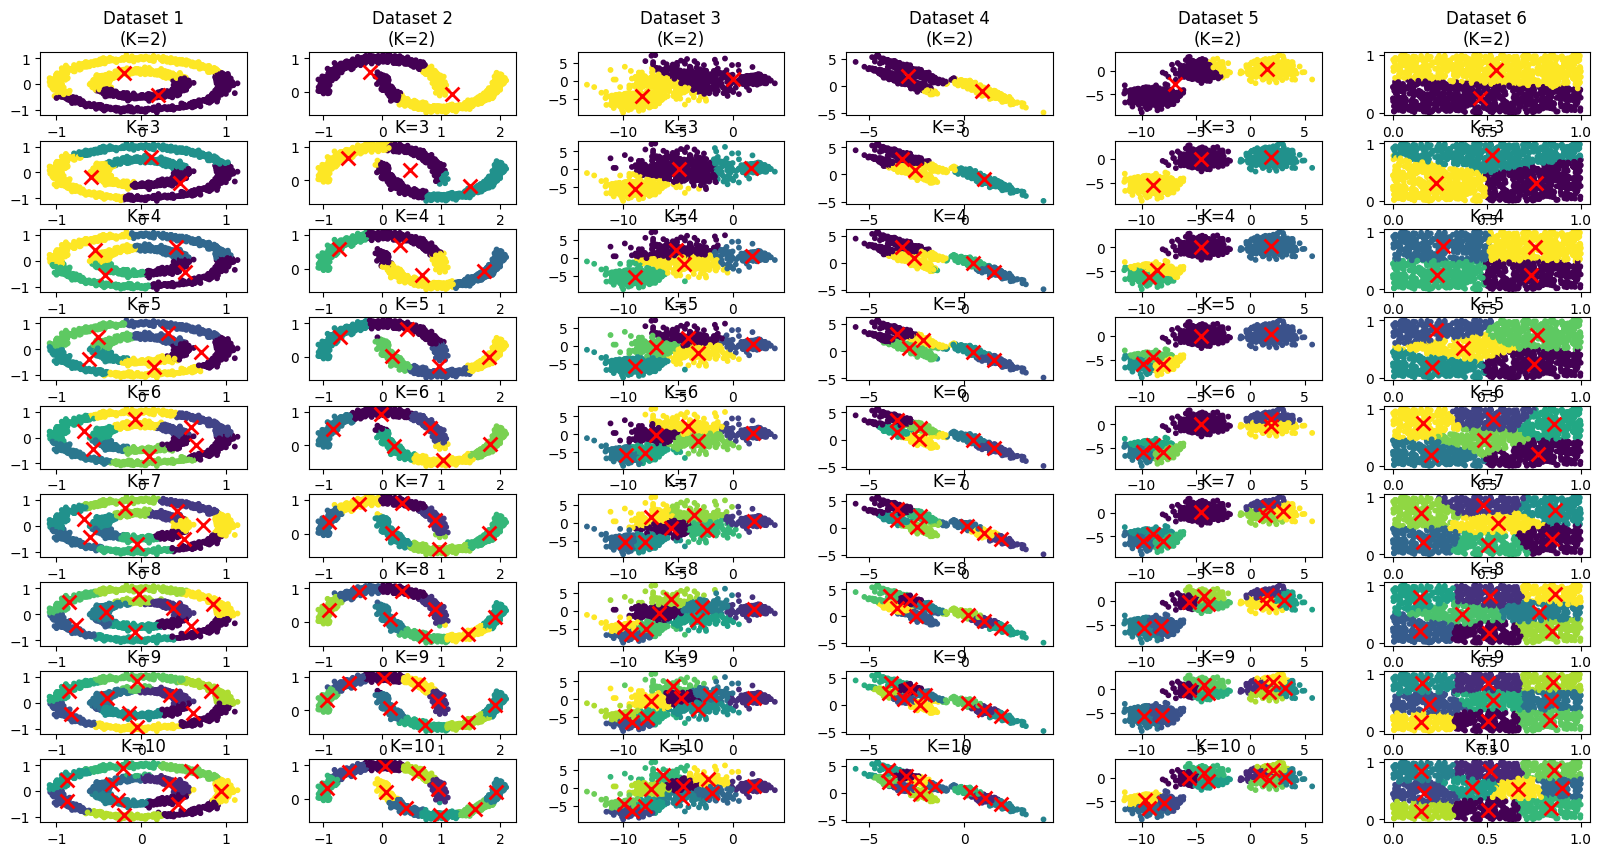

In [18]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# গ্রাফের সাইজ নির্ধারণ (রো সংখ্যা = ৩টি K এর জন্য, কলাম সংখ্যা = ৬টি ডেটাসেটের জন্য)
fig, axs = plt.subplots(9, len(listofdata), figsize=(20, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# K এর ভিন্ন ভিন্ন মান (সেন্ট্রয়েডের সংখ্যা)
k_values = [2, 3, 4, 5, 6 , 7, 8, 9, 10]

for row_idx, k in enumerate(k_values):
    for col_idx, ds in enumerate(listofdata):
        X = ds[0] # ডেটার বৈশিষ্ট্য বা কোঅর্ডিনেট
        
        # K-Means মডেল তৈরি ও ফিট করা
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        y_pred = kmeans.fit_predict(X)
        
        # বর্তমান সাবপ্লট সিলেক্ট করা
        ax = axs[row_idx, col_idx]
        
        # ডেটা পয়েন্টগুলো প্লট করা (K-Means এর প্রেডিকশন অনুযায়ী রঙ হবে)
        ax.scatter(X[:, 0], X[:, 1], c=y_pred, s=10, cmap='viridis')
        
        # সেন্ট্রয়েড বা ক্লাস্টারের কেন্দ্রগুলোকে লাল রঙের 'X' দিয়ে চিহ্নিত করা
        centroids = kmeans.cluster_centers_
        ax.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=100, linewidths=2, color='red')
        
        # শিরোনাম সেট করা
        if row_idx == 0:
            ax.set_title(f"Dataset {col_idx+1}\n(K={k})")
        else:
            ax.set_title(f"K={k}")

plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>